# Code for individual assignment for 02445

Load dataset and drop unnamed column

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("HR_data.csv")
df = df.drop(columns=["Unnamed: 0"])

check

In [2]:
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nIndividuals:", df["Individual"].nunique(), "people")
print("Rows per individual:\n", df["Individual"].value_counts().sort_index())
print("\nCohorts:\n", df["Cohort"].value_counts())
print("\nFrustrated distribution:\n", df["Frustrated"].value_counts().sort_index())

Shape: (168, 12)

Columns: ['HR_Mean', 'HR_Median', 'HR_std', 'HR_Min', 'HR_Max', 'HR_AUC', 'Round', 'Phase', 'Individual', 'Puzzler', 'Frustrated', 'Cohort']

Individuals: 14 people
Rows per individual:
 Individual
1     12
2     12
3     12
4     12
5     12
6     12
7     12
8     12
9     12
10    12
11    12
12    12
13    12
14    12
Name: count, dtype: int64

Cohorts:
 Cohort
D1_1    96
D1_2    72
Name: count, dtype: int64

Frustrated distribution:
 Frustrated
0    29
1    45
2    31
3    16
4    23
5    14
6     5
7     2
8     3
Name: count, dtype: int64


Binarize so low is 0 and high is 1

In [4]:
Threshold = 3
df["Frustrated_bin"] = (df["Frustrated"] >= Threshold).astype(int)

print("Class balance after binarizing at >=", Threshold)
print(df["Frustrated_bin"].value_counts())
print("\nProportion high:", round(df["Frustrated_bin"].mean(), 3))

Class balance after binarizing at >= 3
Frustrated_bin
0    105
1     63
Name: count, dtype: int64

Proportion high: 0.375


Feature selection:
Only using HR features

Individual is pulled out as groups, not used as a feature

In [5]:
feature_cols = ["HR_Mean", "HR_Median", "HR_std", "HR_Min", "HR_Max", "HR_AUC"]

X = df[feature_cols].values
y = df["Frustrated_bin"].values
groups = df["Individual"].values

print("X shape:", X.shape)
print("y shape:", y.shape)
print("n groups (individuals):", len(np.unique(groups)))

X shape: (168, 6)
y shape: (168,)
n groups (individuals): 14


The data has repeated measures (12 rows per person) so a normal random K-fold split would put some of a persons rows in training and some in test. The model could then recognize a person it has partly seen and score well for the wrong reason, i.e leakage that inflates estimate. Leave-one-out prevents it by holding out all 12 rows of one individual as the test set while training on the other 13 people repeated 14 times so every person is the held-out test once. That measures how well the model predcits frustration for a person it has never seen which is the generalization goal.


So first a check on the splits:

In [7]:
from sklearn.model_selection import LeaveOneGroupOut

logo = LeaveOneGroupOut()
print("Number of CV folds:", logo.get_n_splits(X, y, groups))

for fold, (train_idx, test_idx) in enumerate(logo.split(X, y, groups)):
    test_individual = np.unique(groups[test_idx])
    print(f"Fold {fold+1}: test individual = {test_individual}, "
          f"n_train = {len(train_idx)}, n_test = {len(test_idx)}")

Number of CV folds: 14
Fold 1: test individual = [1], n_train = 156, n_test = 12
Fold 2: test individual = [2], n_train = 156, n_test = 12
Fold 3: test individual = [3], n_train = 156, n_test = 12
Fold 4: test individual = [4], n_train = 156, n_test = 12
Fold 5: test individual = [5], n_train = 156, n_test = 12
Fold 6: test individual = [6], n_train = 156, n_test = 12
Fold 7: test individual = [7], n_train = 156, n_test = 12
Fold 8: test individual = [8], n_train = 156, n_test = 12
Fold 9: test individual = [9], n_train = 156, n_test = 12
Fold 10: test individual = [10], n_train = 156, n_test = 12
Fold 11: test individual = [11], n_train = 156, n_test = 12
Fold 12: test individual = [12], n_train = 156, n_test = 12
Fold 13: test individual = [13], n_train = 156, n_test = 12
Fold 14: test individual = [14], n_train = 156, n_test = 12


Building the models => Logistic regression and random forest (1 linear and 1 nonlinear) => If both fail = data is the limitation

The scaler is fit inside each fold on training data only to avoid leakage.
The majority-class baseline is computed per-fold from the training data to ensure a fair comparison.
random_state=42 makes it reproducible

In [8]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

logo = LeaveOneGroupOut()
models = {
    "LogReg": Pipeline([("scaler", StandardScaler()),
                        ("clf", LogisticRegression(max_iter=1000, random_state=42))]),
    "RandomForest": Pipeline([("scaler", StandardScaler()),
                              ("clf", RandomForestClassifier(n_estimators=200, random_state=42))])
}

results = {name: [] for name in models}
baseline_scores = []

for train_idx, test_idx in logo.split(X, y, groups):
    X_tr, X_te = X[train_idx], X[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    majority = np.bincount(y_tr).argmax()
    baseline_scores.append(accuracy_score(y_te, np.full_like(y_te, majority)))

    for name, model in models.items():
        model.fit(X_tr, y_tr)
        pred = model.predict(X_te)
        results[name].append(accuracy_score(y_te, pred))

for name in models:
    arr = np.array(results[name])
    print(f"{name:14s} mean={arr.mean():.3f}  std={arr.std():.3f}")
arr = np.array(baseline_scores)
print(f"{'Baseline':14s} mean={arr.mean():.3f}  std={arr.std():.3f}")

LogReg         mean=0.565  std=0.209
RandomForest   mean=0.506  std=0.188
Baseline       mean=0.625  std=0.191


### Statistical testing

Wilcoxon signed-rank is non-parametric. It ranks the size of the differences and tests whether the positives and negatives balance without assuming normality.

Paired t-test assumes normal distribution and works on the mean so it is to check if the mean difference is far enough from zero relative to its spread to be unlikely

Since it is only 14 folds, wilcoxon is the primary test as I assume no normality. t-test is a cross check so if they both agree, the conclusion is stronger.

In [9]:
from scipy import stats

lr = np.array(results["LogReg"])
rf = np.array(results["RandomForest"])

w_stat, w_p = stats.wilcoxon(lr, rf)
print(f"Wilcoxon signed-rank: W = {w_stat:.1f}, p = {w_p:.4f}")

t_stat, t_p = stats.ttest_rel(lr, rf)
print(f"Paired t-test:        t = {t_stat:.3f}, p = {t_p:.4f}")

print(f"\nLogReg mean = {lr.mean():.3f}, RF mean = {rf.mean():.3f}, diff = {lr.mean()-rf.mean():.3f}")

Wilcoxon signed-rank: W = 25.0, p = 0.2712
Paired t-test:        t = 1.256, p = 0.2312

LogReg mean = 0.565, RF mean = 0.506, diff = 0.060


Target distribution => The original 0-8 ratings are skewed toward the low end with a sparse tail (few examples above 5), which is why I binarize. The right panel shows the resulting split: 105 low, 63 high, giving a majority baseline of 0.625.

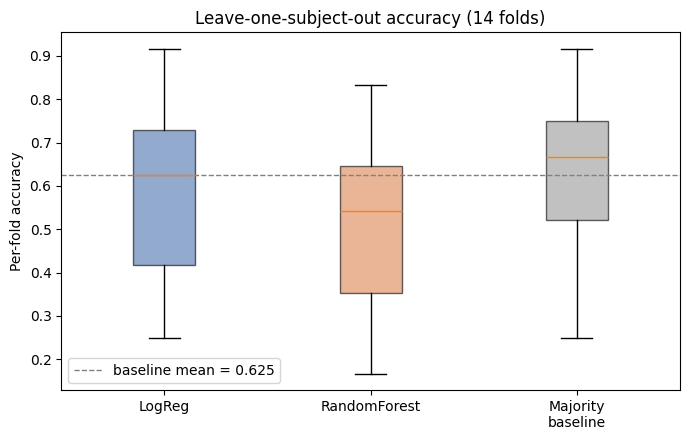

In [10]:
import matplotlib.pyplot as plt

data = [results["LogReg"], results["RandomForest"], baseline_scores]
labels = ["LogReg", "RandomForest", "Majority\nbaseline"]

fig, ax = plt.subplots(figsize=(7, 4.5))
bp = ax.boxplot(data, tick_labels=labels, patch_artist=True)
for patch, c in zip(bp["boxes"], ["#4C72B0", "#DD8452", "#999999"]):
    patch.set_facecolor(c)
    patch.set_alpha(0.6)

ax.axhline(np.mean(baseline_scores), ls="--", color="grey", lw=1,
           label=f"baseline mean = {np.mean(baseline_scores):.3f}")
ax.set_ylabel("Per-fold accuracy")
ax.set_title("Leave-one-subject-out accuracy (14 folds)")
ax.legend()
plt.tight_layout()
plt.show()

Per-fold accuracy across the 14 leave-one-subject-out folds. Both models straddle the baseline rather than beating it and the large spread of each box reflects the strong between-subject variability. The overlap between all three boxes matches the non-significant Wilcoxon result.

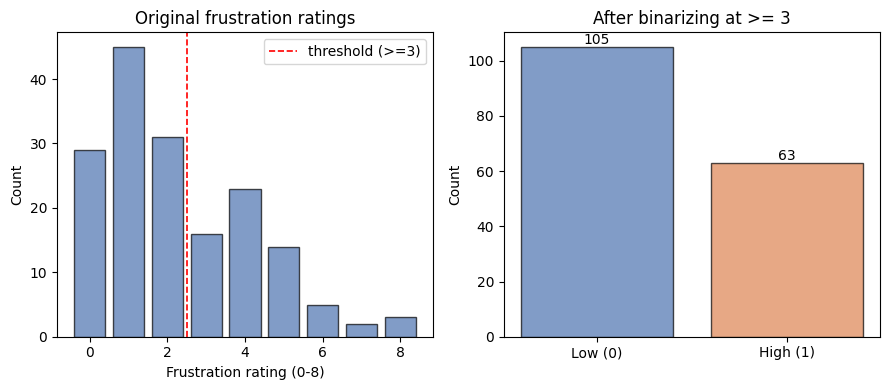

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

counts = df["Frustrated"].value_counts().sort_index()
axes[0].bar(counts.index, counts.values, color="#4C72B0", alpha=0.7, edgecolor="black")
axes[0].axvline(2.5, ls="--", color="red", lw=1.2, label="threshold (>=3)")
axes[0].set_xlabel("Frustration rating (0-8)")
axes[0].set_ylabel("Count")
axes[0].set_title("Original frustration ratings")
axes[0].legend()

binc = df["Frustrated_bin"].value_counts().sort_index()
axes[1].bar(["Low (0)", "High (1)"], binc.values,
            color=["#4C72B0", "#DD8452"], alpha=0.7, edgecolor="black")
axes[1].set_ylabel("Count")
axes[1].set_title("After binarizing at >= 3")
for i, v in enumerate(binc.values):
    axes[1].text(i, v + 1, str(v), ha="center")

plt.tight_layout()
plt.show()